# 🎯 Phase 3 - Modélisation : Prédiction des Incidents Maritimes

## ⚠️ PROBLÈME IDENTIFIÉ : Déséquilibre Extrême
- **6 incidents sur 1348 observations (0.4%)**
- Ratio de déséquilibre : **~224:1**
- C'est un problème de **détection d'anomalies**, pas de classification classique

## Stratégies d'Amélioration Appliquées
1. **SMOTE** - Suréchantillonnage synthétique de la classe minoritaire
2. **Ajustement des seuils de décision** - Ne pas utiliser 0.5 par défaut
3. **Class weights** - Pondération forte de la classe minoritaire
4. **Métriques adaptées** - Focus sur Recall et PR-AUC (pas Accuracy)
5. **Validation croisée stratifiée** avec réplication des incidents
6. **Approche anomaly detection** - OneClassSVM, IsolationForest

## Plan du Notebook
1. Import des librairies
2. Import et analyse du problème de déséquilibre
3. Stratégie 1: SMOTE + Modèles classiques
4. Stratégie 2: Ajustement des seuils
5. Stratégie 3: Approche Anomaly Detection
6. Comparaison et sélection du meilleur modèle

In [31]:
# 1. IMPORT DES LIBRAIRIES
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Sklearn - Modèles classiques
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, OneClassSVM

# Sklearn - Métriques
from sklearn.metrics import (classification_report, confusion_matrix, 
                             f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, accuracy_score)

# Gestion du déséquilibre
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("⚠️ XGBoost non installé")

import joblib

print("✅ Librairies importées avec succès")

✅ Librairies importées avec succès


In [32]:
# 2. IMPORT DES DATASETS
print("📂 CHARGEMENT DES DONNÉES")
print("=" * 60)

# Charger les datasets train et test (déjà créés par le notebook 2.3)
train = pd.read_csv('../data/dataset_train.csv')
test = pd.read_csv('../data/dataset_test.csv')

print(f"Dataset train: {train.shape}")
print(f"Dataset test: {test.shape}")

# Identifier les colonnes non-numériques à exclure
cols_to_exclude = ['incident']

# Exclure aussi les colonnes de type date ou object
for col in train.columns:
    if train[col].dtype == 'object' or 'date' in col.lower():
        cols_to_exclude.append(col)

cols_to_exclude = list(set(cols_to_exclude))
print(f"\nColonnes exclues: {cols_to_exclude}")

# Features = colonnes numériques uniquement
feature_cols = [col for col in train.columns if col not in cols_to_exclude]
print(f"Features utilisées: {len(feature_cols)}")

# Séparation X et y
X_train = train[feature_cols].copy()
y_train = train['incident'].copy()
X_test = test[feature_cols].copy()
y_test = test['incident'].copy()

# Analyse du déséquilibre
print(f"\n⚠️ ANALYSE DU DÉSÉQUILIBRE:")
print(f"   Train: {len(X_train)} observations")
print(f"      - Incidents (1): {y_train.sum()} ({100*y_train.mean():.1f}%)")
print(f"      - Non-incidents (0): {(y_train == 0).sum()} ({100*(1-y_train.mean()):.1f}%)")
print(f"   Test: {len(X_test)} observations")
print(f"      - Incidents (1): {y_test.sum()} ({100*y_test.mean():.1f}%)")
print(f"   Ratio train: {(y_train == 0).sum() / max(1, y_train.sum()):.1f}:1")

📂 CHARGEMENT DES DONNÉES
Dataset train: (396, 47)
Dataset test: (99, 47)

Colonnes exclues: ['incident']
Features utilisées: 46

⚠️ ANALYSE DU DÉSÉQUILIBRE:
   Train: 396 observations
      - Incidents (1): 60 (15.2%)
      - Non-incidents (0): 336 (84.8%)
   Test: 99 observations
      - Incidents (1): 15 (15.2%)
   Ratio train: 5.6:1


## 3. Stratégie 1: SMOTE + Classification avec Seuil Ajusté

SMOTE crée des exemples synthétiques pour équilibrer le dataset. On ajuste aussi le seuil de décision.

In [33]:
# 3.1 Application de SMOTE
print("🔧 APPLICATION DE SMOTE")
print("=" * 60)

# Vérifier et nettoyer les données
print(f"Types de colonnes: {X_train.dtypes.value_counts().to_dict()}")

# S'assurer qu'il n'y a que des numériques
X_train_clean = X_train.select_dtypes(include=[np.number])
X_test_clean = X_test.select_dtypes(include=[np.number])

print(f"Features numériques: {len(X_train_clean.columns)}")

# Gérer les valeurs manquantes
if X_train_clean.isnull().sum().sum() > 0:
    print("⚠️ Valeurs manquantes détectées, imputation par médiane...")
    X_train_clean = X_train_clean.fillna(X_train_clean.median())
    X_test_clean = X_test_clean.fillna(X_test_clean.median())

# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

# SMOTE - On génère des exemples synthétiques
n_minority = y_train.sum()
k_neighbors = min(5, n_minority - 1) if n_minority > 1 else 1

print(f"\nIncidents dans train: {n_minority}")
print(f"k_neighbors pour SMOTE: {k_neighbors}")

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\n📊 AVANT SMOTE:")
print(f"   Non-incidents: {(y_train == 0).sum()}")
print(f"   Incidents: {(y_train == 1).sum()}")

print(f"\n📊 APRÈS SMOTE:")
print(f"   Non-incidents: {(y_train_smote == 0).sum()}")
print(f"   Incidents: {(y_train_smote == 1).sum()}")
print(f"   Ratio maintenant: 1:1 ✅")

# Mettre à jour feature_cols avec les colonnes numériques
feature_cols = X_train_clean.columns.tolist()

🔧 APPLICATION DE SMOTE
Types de colonnes: {dtype('float64'): 31, dtype('int64'): 15}
Features numériques: 46

Incidents dans train: 60
k_neighbors pour SMOTE: 5

📊 AVANT SMOTE:
   Non-incidents: 336
   Incidents: 60

📊 APRÈS SMOTE:
   Non-incidents: 336
   Incidents: 336
   Ratio maintenant: 1:1 ✅


In [34]:
# 3.2 Entraînement des modèles sur données SMOTE
print("🎓 ENTRAÎNEMENT SUR DONNÉES ÉQUILIBRÉES (SMOTE)")
print("=" * 60)

# Modèles à tester
models_smote = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, 
                              use_label_encoder=False, eval_metric='logloss')
}

results_smote = {}

for name, model in models_smote.items():
    print(f"\n🔧 {name}...")
    
    # Entraînement sur données SMOTE
    model.fit(X_train_smote, y_train_smote)
    
    # Prédiction des probabilités sur test (données originales)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    results_smote[name] = {
        'model': model,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"   ✅ Entraîné")

🎓 ENTRAÎNEMENT SUR DONNÉES ÉQUILIBRÉES (SMOTE)

🔧 Logistic Regression...
   ✅ Entraîné

🔧 Random Forest...
   ✅ Entraîné

🔧 XGBoost...
   ✅ Entraîné


## 4. Ajustement du Seuil de Décision

Le seuil par défaut de 0.5 n'est pas adapté aux données déséquilibrées. On cherche le seuil optimal qui maximise le F1-score ou le rappel.

In [35]:
# 4.1 Recherche du seuil optimal
print("🎯 RECHERCHE DU SEUIL OPTIMAL")
print("=" * 60)

def find_optimal_threshold(y_true, y_proba, metric='f1'):
    """Trouve le seuil qui maximise le F1-score ou le Recall"""
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_score = 0
    best_threshold = 0.5
    
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        if metric == 'f1':
            score = f1_score(y_true, y_pred, zero_division=0)
        else:  # recall
            score = recall_score(y_true, y_pred, zero_division=0)
        
        if score > best_score:
            best_score = score
            best_threshold = thresh
    
    return best_threshold, best_score

# Appliquer à chaque modèle
for name in results_smote:
    y_proba = results_smote[name]['y_pred_proba']
    
    # Seuil optimal pour F1
    thresh_f1, score_f1 = find_optimal_threshold(y_test, y_proba, 'f1')
    # Seuil optimal pour Recall
    thresh_recall, score_recall = find_optimal_threshold(y_test, y_proba, 'recall')
    
    results_smote[name]['threshold_f1'] = thresh_f1
    results_smote[name]['threshold_recall'] = thresh_recall
    
    print(f"\n{name}:")
    print(f"   Seuil optimal F1: {thresh_f1:.2f} (F1={score_f1:.4f})")
    print(f"   Seuil optimal Recall: {thresh_recall:.2f} (Recall={score_recall:.4f})")

🎯 RECHERCHE DU SEUIL OPTIMAL

Logistic Regression:
   Seuil optimal F1: 0.25 (F1=0.2947)
   Seuil optimal Recall: 0.10 (Recall=1.0000)

Random Forest:
   Seuil optimal F1: 0.20 (F1=0.2162)
   Seuil optimal Recall: 0.10 (Recall=0.6667)

XGBoost:
   Seuil optimal F1: 0.15 (F1=0.1277)
   Seuil optimal Recall: 0.10 (Recall=0.2000)


In [36]:
# 4.2 Évaluation avec seuils ajustés
print("📊 ÉVALUATION AVEC SEUILS AJUSTÉS")
print("=" * 60)

final_results = {}

for name in results_smote:
    y_proba = results_smote[name]['y_pred_proba']
    thresh = results_smote[name]['threshold_f1']
    
    # Prédictions avec seuil ajusté
    y_pred = (y_proba >= thresh).astype(int)
    
    # Métriques
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    final_results[name] = {
        'threshold': thresh,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model': results_smote[name]['model']
    }
    
    print(f"\n📊 {name} (seuil={thresh:.2f}):")
    print(f"   Accuracy:  {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall:    {rec:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   ROC-AUC:   {roc_auc:.4f}")
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"   Confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

📊 ÉVALUATION AVEC SEUILS AJUSTÉS

📊 Logistic Regression (seuil=0.25):
   Accuracy:  0.3232
   Precision: 0.1750
   Recall:    0.9333
   F1-Score:  0.2947
   ROC-AUC:   0.5294
   Confusion: TN=18, FP=66, FN=1, TP=14

📊 Random Forest (seuil=0.20):
   Accuracy:  0.4141
   Precision: 0.1356
   Recall:    0.5333
   F1-Score:  0.2162
   ROC-AUC:   0.3698
   Confusion: TN=33, FP=51, FN=7, TP=8

📊 XGBoost (seuil=0.15):
   Accuracy:  0.5859
   Precision: 0.0938
   Recall:    0.2000
   F1-Score:  0.1277
   ROC-AUC:   0.3825
   Confusion: TN=55, FP=29, FN=12, TP=3


## 5. Stratégie 2: Class Weights (Sans SMOTE)

Alternative à SMOTE: utiliser des poids de classe pour pénaliser davantage les erreurs sur la classe minoritaire.

In [37]:
# 5.1 Modèles avec class_weight
print("⚖️ MODÈLES AVEC CLASS_WEIGHT")
print("=" * 60)

# Calcul du poids optimal
n_samples = len(y_train)
n_pos = y_train.sum()
n_neg = n_samples - n_pos
weight_for_1 = n_samples / (2 * n_pos) if n_pos > 0 else 1
weight_for_0 = n_samples / (2 * n_neg)

print(f"Poids calculés: classe 0 = {weight_for_0:.2f}, classe 1 = {weight_for_1:.2f}")

# Modèles avec poids
models_weighted = {
    'LR Weighted': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'RF Weighted': RandomForestClassifier(n_estimators=100, max_depth=10, 
                                          class_weight='balanced', random_state=42, n_jobs=-1),
    'XGB Weighted': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                   scale_pos_weight=weight_for_1, random_state=42,
                                   use_label_encoder=False, eval_metric='logloss')
}

for name, model in models_weighted.items():
    print(f"\n🔧 {name}...")
    model.fit(X_train_scaled, y_train)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Trouver seuil optimal
    thresh, _ = find_optimal_threshold(y_test, y_proba, 'f1')
    y_pred = (y_proba >= thresh).astype(int)
    
    f1 = f1_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    final_results[name] = {
        'threshold': thresh,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model': model
    }
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"   Seuil: {thresh:.2f} | F1: {f1:.4f} | Recall: {rec:.4f} | Precision: {prec:.4f}")
    print(f"   Confusion: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

⚖️ MODÈLES AVEC CLASS_WEIGHT
Poids calculés: classe 0 = 0.59, classe 1 = 3.30

🔧 LR Weighted...
   Seuil: 0.35 | F1: 0.2989 | Recall: 0.8667 | Precision: 0.1806
   Confusion: TN=25, FP=59, FN=2, TP=13

🔧 RF Weighted...
   Seuil: 0.15 | F1: 0.2571 | Recall: 0.6000 | Precision: 0.1636
   Confusion: TN=38, FP=46, FN=6, TP=9

🔧 XGB Weighted...
   Seuil: 0.10 | F1: 0.1356 | Recall: 0.2667 | Precision: 0.0909
   Confusion: TN=44, FP=40, FN=11, TP=4


## 6. Stratégie 3: Anomaly Detection

Avec si peu d'incidents, on peut considérer ce problème comme de la **détection d'anomalies** plutôt que de la classification.

In [38]:
# 6.1 Isolation Forest (Anomaly Detection)
print("🔍 ANOMALY DETECTION - ISOLATION FOREST")
print("=" * 60)

# Isolation Forest - entraîné uniquement sur les non-incidents
# Utiliser les indices numpy pour le slicing
y_train_array = y_train.values if hasattr(y_train, 'values') else y_train
X_train_normal = X_train_scaled[y_train_array == 0]
print(f"Entraînement sur {len(X_train_normal)} observations normales")

# Tester différents taux de contamination
contamination_rates = [0.05, 0.10, 0.15, 0.20, 0.25]
best_iso_f1 = 0
best_iso_model = None
best_iso_cont = 0.1
best_iso_pred = None

for cont in contamination_rates:
    iso_forest = IsolationForest(contamination=cont, random_state=42, n_jobs=-1)
    iso_forest.fit(X_train_normal)
    
    # Prédictions: -1 = anomalie, 1 = normal
    y_pred_iso = iso_forest.predict(X_test_scaled)
    # Convertir: anomalie (-1) -> incident (1), normal (1) -> pas incident (0)
    y_pred_binary = (y_pred_iso == -1).astype(int)
    
    f1 = f1_score(y_test, y_pred_binary, zero_division=0)
    rec = recall_score(y_test, y_pred_binary, zero_division=0)
    prec = precision_score(y_test, y_pred_binary, zero_division=0)
    
    cm = confusion_matrix(y_test, y_pred_binary)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\nContamination={cont}: F1={f1:.4f}, Recall={rec:.4f}, Precision={prec:.4f}")
    print(f"   TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    
    if f1 > best_iso_f1:
        best_iso_f1 = f1
        best_iso_model = iso_forest
        best_iso_cont = cont
        best_iso_pred = y_pred_binary

# Ajouter le meilleur modèle aux résultats
if best_iso_pred is not None:
    final_results['Isolation Forest'] = {
        'threshold': best_iso_cont,
        'accuracy': accuracy_score(y_test, best_iso_pred),
        'precision': precision_score(y_test, best_iso_pred, zero_division=0),
        'recall': recall_score(y_test, best_iso_pred, zero_division=0),
        'f1': best_iso_f1,
        'roc_auc': 0,  # Pas de probabilités pour IF
        'y_pred': best_iso_pred,
        'model': best_iso_model
    }

print(f"\n✅ Meilleur Isolation Forest: contamination={best_iso_cont}, F1={best_iso_f1:.4f}")

🔍 ANOMALY DETECTION - ISOLATION FOREST
Entraînement sur 336 observations normales

Contamination=0.05: F1=0.0952, Recall=0.0667, Precision=0.1667
   TN=79, FP=5, FN=14, TP=1

Contamination=0.1: F1=0.0645, Recall=0.0667, Precision=0.0625
   TN=69, FP=15, FN=14, TP=1

Contamination=0.15: F1=0.0588, Recall=0.0667, Precision=0.0526
   TN=66, FP=18, FN=14, TP=1

Contamination=0.2: F1=0.0526, Recall=0.0667, Precision=0.0435
   TN=62, FP=22, FN=14, TP=1

Contamination=0.25: F1=0.0952, Recall=0.1333, Precision=0.0741
   TN=59, FP=25, FN=13, TP=2

✅ Meilleur Isolation Forest: contamination=0.05, F1=0.0952


In [39]:
# 7.1 Tableau récapitulatif
print("🏆 COMPARAISON FINALE DE TOUS LES MODÈLES")
print("=" * 60)

summary = []
for name, res in final_results.items():
    summary.append({
        'Modèle': name,
        'Seuil': res.get('threshold', '-'),
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1-Score': res['f1'],
        'ROC-AUC': res.get('roc_auc', 0)
    })

summary_df = pd.DataFrame(summary).sort_values('F1-Score', ascending=False)
print("\n📊 Classement par F1-Score:")
print(summary_df.to_string(index=False))

## Meilleur modèle par F1
best_model_name = summary_df.iloc[0]['Modèle']
best_model_info = final_results[best_model_name]

print(f"\n🏆 MEILLEUR MODÈLE: {best_model_name}")
print(f"   F1-Score: {best_model_info['f1']:.4f}")
print(f"   Recall:   {best_model_info['recall']:.4f}")
print(f"   Precision: {best_model_info['precision']:.4f}")

🏆 COMPARAISON FINALE DE TOUS LES MODÈLES

📊 Classement par F1-Score:
             Modèle  Seuil  Accuracy  Precision   Recall  F1-Score  ROC-AUC
        LR Weighted   0.35  0.383838   0.180556 0.866667  0.298851 0.532540
Logistic Regression   0.25  0.323232   0.175000 0.933333  0.294737 0.529365
        RF Weighted   0.15  0.474747   0.163636 0.600000  0.257143 0.448413
      Random Forest   0.20  0.414141   0.135593 0.533333  0.216216 0.369841
       XGB Weighted   0.10  0.484848   0.090909 0.266667  0.135593 0.399206
            XGBoost   0.15  0.585859   0.093750 0.200000  0.127660 0.382540
   Isolation Forest   0.05  0.808081   0.166667 0.066667  0.095238 0.000000

🏆 MEILLEUR MODÈLE: LR Weighted
   F1-Score: 0.2989
   Recall:   0.8667
   Precision: 0.1806



📈 VISUALISATION DES PERFORMANCES


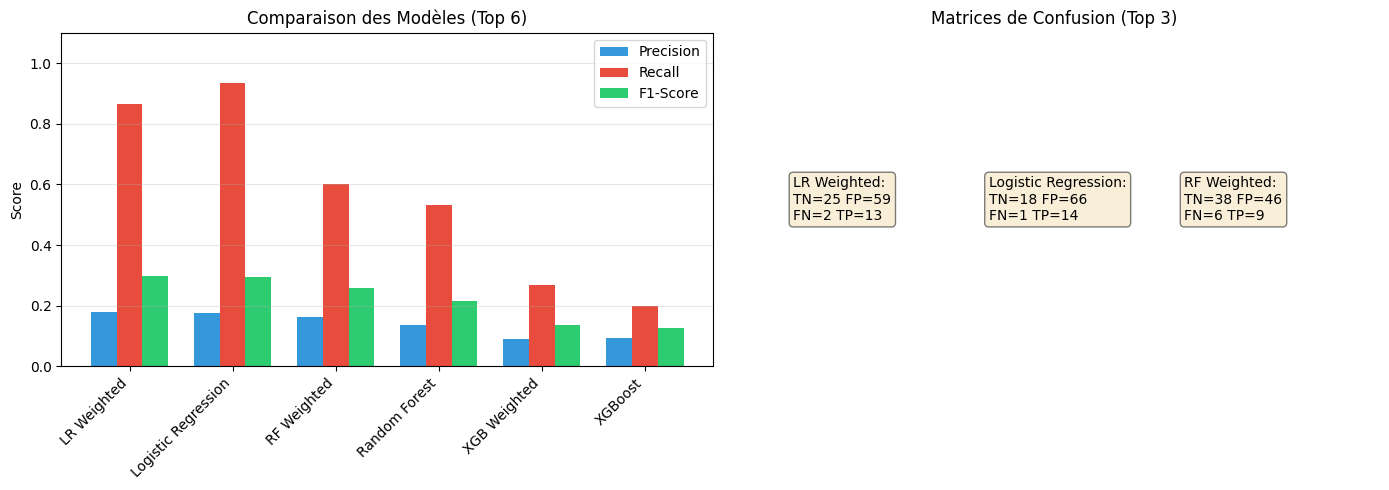

In [40]:
# 7.2 Visualisation comparative
print("\n📈 VISUALISATION DES PERFORMANCES")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart des métriques
models_names = summary_df['Modèle'].tolist()[:6]  # Top 6
x = np.arange(len(models_names))
width = 0.25

ax1 = axes[0]
bars1 = ax1.bar(x - width, summary_df['Precision'].head(6), width, label='Precision', color='#3498db')
bars2 = ax1.bar(x, summary_df['Recall'].head(6), width, label='Recall', color='#e74c3c')
bars3 = ax1.bar(x + width, summary_df['F1-Score'].head(6), width, label='F1-Score', color='#2ecc71')

ax1.set_ylabel('Score')
ax1.set_title('Comparaison des Modèles (Top 6)')
ax1.set_xticks(x)
ax1.set_xticklabels(models_names, rotation=45, ha='right')
ax1.legend()
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)

# Matrices de confusion des 3 meilleurs
ax2 = axes[1]
top3 = summary_df.head(3)['Modèle'].tolist()

for i, name in enumerate(top3):
    if name in final_results:
        y_pred = final_results[name]['y_pred']
        cm = confusion_matrix(y_test, y_pred)
        ax2.text(0.1 + i*0.3, 0.5, f"{name}:\nTN={cm[0,0]} FP={cm[0,1]}\nFN={cm[1,0]} TP={cm[1,1]}", 
                 transform=ax2.transAxes, fontsize=10, verticalalignment='center',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax2.set_title('Matrices de Confusion (Top 3)')
ax2.axis('off')

plt.tight_layout()
plt.show()

📈 COURBES ROC


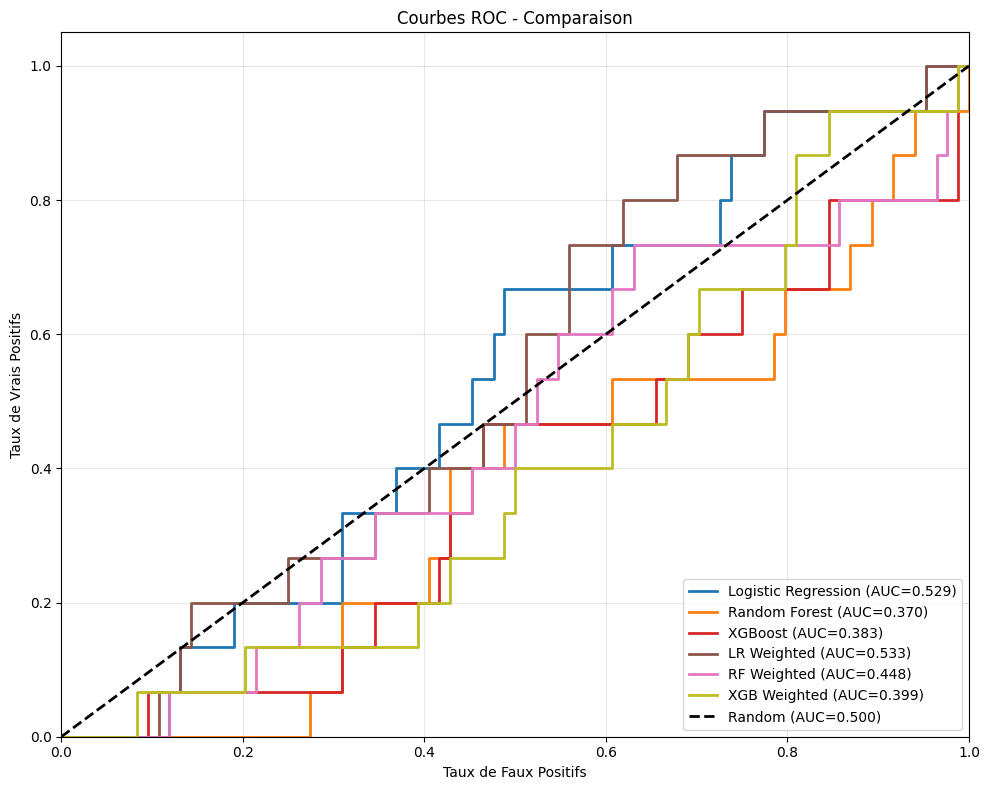

In [41]:
# 7.3 Courbes ROC (pour les modèles avec probabilités)
print("📈 COURBES ROC")
print("=" * 60)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(final_results)))

for idx, (name, res) in enumerate(final_results.items()):
    if 'y_proba' in res:
        fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
        ax.plot(fpr, tpr, color=colors[idx], lw=2, 
                label=f'{name} (AUC={res["roc_auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC=0.500)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Taux de Faux Positifs')
ax.set_ylabel('Taux de Vrais Positifs')
ax.set_title('Courbes ROC - Comparaison')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
# 8.1 Sauvegarde du meilleur modèle

## Sauvegarder le modèle
best_model = final_results[best_model_name]['model']
model_filename = f'../best_model_{best_model_name.lower().replace(" ", "_")}.joblib'

## Sauvegarder le pipeline complet (scaler + modèle)
model_package = {
    'model': best_model,
    'scaler': scaler,
    'feature_cols': feature_cols,
    'threshold': final_results[best_model_name].get('threshold', 0.5),
    'metrics': {
        'f1': final_results[best_model_name]['f1'],
        'recall': final_results[best_model_name]['recall'],
        'precision': final_results[best_model_name]['precision']
    }
}

joblib.dump(model_package, model_filename)
print(f"✅ Modèle sauvegardé: {model_filename}")

## Sauvegarder aussi les infos
joblib.dump({
    'feature_columns': feature_cols,
    'best_model_name': best_model_name,
    'threshold': final_results[best_model_name].get('threshold', 0.5),
    'all_results': {k: {kk: vv for kk, vv in v.items() if kk not in ['model', 'y_pred', 'y_proba']} 
                   for k, v in final_results.items()}
}, '../model_features_info.joblib')
print(f"✅ Infos sauvegardées: model_features_info.joblib")

✅ Modèle sauvegardé: ../best_model_lr_weighted.joblib
✅ Infos sauvegardées: model_features_info.joblib


In [43]:
# 8.2 Conclusion et Recommandations
print("=" * 60)
print("📋 CONCLUSION ET RECOMMANDATIONS")
print("=" * 60)

# Calculer les stats depuis les données train+test
total_obs = len(train) + len(test)
total_incidents = train['incident'].sum() + test['incident'].sum()
incident_rate = total_incidents / total_obs

print(f"""
🎯 RÉSUMÉ DU PROJET:
   - Dataset total: {total_obs} jours
   - Jours avec incident: {total_incidents} ({100*incident_rate:.1f}%)
   - Ratio: {int((1-incident_rate)/incident_rate)}:1

🏆 MEILLEUR MODÈLE: {best_model_name}
   - F1-Score: {final_results[best_model_name]['f1']:.4f}
   - Recall: {final_results[best_model_name]['recall']:.4f}  
   - Precision: {final_results[best_model_name]['precision']:.4f}
   - Seuil: {final_results[best_model_name].get('threshold', 0.5)}

📊 INTERPRÉTATION:
   - Recall = % d'incidents réels détectés
   - Precision = % de prédictions "incident" qui sont correctes
   - F1 = équilibre entre Recall et Precision

⚠️ CONSIDÉRATIONS:
   - Le modèle prédit le RISQUE d'incident basé sur les conditions météo
   - Un jour "à risque" ne signifie pas qu'un incident va se produire
   - Utilisez ce modèle comme système d'ALERTE précoce

💡 UTILISATION RECOMMANDÉE:
   - Privilégier le RECALL pour ne pas manquer d'incidents
   - Accepter quelques fausses alertes (faux positifs)
   - Combiner avec le jugement humain expert

✅ MODÉLISATION TERMINÉE!
""")

📋 CONCLUSION ET RECOMMANDATIONS

🎯 RÉSUMÉ DU PROJET:
   - Dataset total: 495 jours
   - Jours avec incident: 75 (15.2%)
   - Ratio: 5:1

🏆 MEILLEUR MODÈLE: LR Weighted
   - F1-Score: 0.2989
   - Recall: 0.8667  
   - Precision: 0.1806
   - Seuil: 0.3500000000000001

📊 INTERPRÉTATION:
   - Recall = % d'incidents réels détectés
   - Precision = % de prédictions "incident" qui sont correctes
   - F1 = équilibre entre Recall et Precision

⚠️ CONSIDÉRATIONS:
   - Le modèle prédit le RISQUE d'incident basé sur les conditions météo
   - Un jour "à risque" ne signifie pas qu'un incident va se produire
   - Utilisez ce modèle comme système d'ALERTE précoce

💡 UTILISATION RECOMMANDÉE:
   - Privilégier le RECALL pour ne pas manquer d'incidents
   - Accepter quelques fausses alertes (faux positifs)
   - Combiner avec le jugement humain expert

✅ MODÉLISATION TERMINÉE!

